COX2-Ibuprofen Docking Project


## Google Drive Connect


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.makedirs('/content/drive/MyDrive/Drug_Discovery/Docking_Projects/', exist_ok=True)

%cd /content/drive/MyDrive/Drug_Discovery/Docking_Projects/

/content/drive/MyDrive/Drug_Discovery/Docking_Projects


## Installing Tools:

RDKit      — molecule preparation

Meeko      — ligand to PDBQT conversion

Vina       — molecular docking engine

PDBFixer   — protein cleaning & repair

OpenBabel  — file format conversion

In [3]:
!pip install rdkit meeko pdbfixer gemmi -q

!pip install gemmi -q         #meeko depends on gemmi
!pip install openbabel-wheel -q
import rdkit
import meeko


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.9/665.9 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 82.5 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [4]:
# Download Vina binary
!wget https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64 -O/content/drive/MyDrive/Drug_Discovery/Docking_Projects/ vina -q
!chmod +x /content/drive/MyDrive/Drug_Discovery/Docking_Projects/vina


# Test
!./vina --version

/content/drive/MyDrive/Drug_Discovery/Docking_Projects/: Is a directory
AutoDock Vina v1.2.5


Downloading protein directly from python using a built in python libarary (urllib) that handles URLs.

In [5]:
# Protein download from protein data bank
# urllib: a build in python library, handles URLs
import urllib.request
url = "https://files.rcsb.org/download/1CX2.pdb"

urllib.request.urlretrieve(url, '1CX2.pdb')


('1CX2.pdb', <http.client.HTTPMessage at 0x7a907ea2ee90>)

In [6]:
# Checking the file size is ok or not
size = os.path.getsize('1CX2.pdb')
print(f"   File size: {size:,} bytes")

   File size: 1,944,000 bytes


***PDB terminology: ***
* ATOM   = protein atoms (amino acids) → the actual protein
* HETATM = Hetero Atom, heterogens → everything else

🧪 **Why Protein Needs Cleaning**

Protein from the Protein Data Bank is not ready for docking.

Cleaning helps ensure correct Protein-ligand interaction.

cleaning for:

Remove water → avoid false results.
Remove old ligands → free active site.
Add hydrogens → needed for bonding.
Add charges → correct energy calculation.
Remove unrelevant or extra chains → to reduce slows down docking, less the increase noise.
Keep main chain → reduce noise.

👉 Result:
Clean protein = accurate docking ✔
Unclean protein = wrong results ❌

Clean protein to remove unwanted molecules and add hydrogens/charges(interaction purpose) for accurate docking results

ATOM -- keep, HETATOM -- Remove

In [7]:
#  Clean the COX-2 Protein

def clean_protein(input_pdb, output_pdb):


    kept_lines = []       # Empty basket — we'll put clean lines here
    skipped = 0

    # trash list(molecules to remove)
    remove_residues = {
        'HOH', 'WAT',   # water molecules
        'SC5', 'SC8',   # SC-558 (the existing drug in 1CX2)
        'HEM',          # heme group (cofactor)
        'SO4', 'GOL',   # crystallography chemicals
        'EDO', 'PEG',   # other lab artifacts
    }

    # Read(r) the input file one line at a time as f (using with: automatically closed the file after work)
    with open(input_pdb, 'r') as f:
        for line in f:

            # ____Remove unwanted molecules
            # If line is a non-protein molecule (HETATM)
            if line.startswith('HETATM'):
                residue_name = line[17:20].strip()   # read residue name
                if residue_name in remove_residues:
                    continue                         # skip (throw away)


             # ___Fix broken coordinate lines
            if line.startswith(('ATOM', 'HETATM')):    # Only line start with ATOM/HETATM contains cordinate

                try:
                    float(line[30:38].strip())  # read X cordinate
                    float(line[38:46].strip())  # Y cordinate
                    float(line[46:54].strip())  # Z cordinate

                except ValueError:
                    skipped += 1                # count broken lines
                    continue


            # Everything else → keep it
            kept_lines.append(line)


    # Save(write, w) clean lines to new file as f
    with open(output_pdb, 'w') as f:
        f.writelines(kept_lines)

    print(f"✅ Protein cleaned and saved as: {output_pdb}")
    print(f"   Removed: water, SC-558 inhibitor, heme, artifacts")



# function calling
clean_protein('1CX2.pdb', 'cox2_clean.pdb')

# checking cleaned pdb file size
size = os.path.getsize('cox2_clean.pdb')
print(f"   File size: {size:,} bytes")

✅ Protein cleaned and saved as: cox2_clean.pdb
   Removed: water, SC-558 inhibitor, heme, artifacts
   File size: 1,930,068 bytes


# Fixing & Preaparing of Protein

* Sometimes amino acids get chemically modified (oxidized, phosphorylated etc.)and become non-standard, need to removed and then replaced with corresponding stnd. version

In [8]:
!pip install pdbfixer -q
from pdbfixer import PDBFixer
from openmm.app import PDBFile


In [9]:
# loading of the clean protein
fixer = PDBFixer(filename = 'cox2_clean.pdb')

# find the missing residue in pdb file
fixer.findMissingResidues()

# find non-standard residue
fixer.findNonstandardResidues()

# replace non-standard residue
fixer.replaceNonstandardResidues()

# remove any hetero atom if exist
fixer.removeHeterogens(True)   # also dlt water(True used for)

# find and add missing atoms
fixer.findMissingAtoms()
fixer.addMissingAtoms()     # add atom that should be in the file, in right places

# adding H2
fixer.addMissingHydrogens(7.4)  #7.4 is the pH of human blood/cytoplasm (balanced charges)

# saveing the fixer file after treatment
with open('cox2_fixed.pdb', 'w') as f:
  PDBFile.writeFile(fixer.topology, fixer.positions, file = f) # atom map, coordinates, save file


# checking size
size = os.path.getsize('cox2_fixed.pdb')
print(f" File size: {size:,} bytes")


 File size: 3,051,695 bytes


***AutoDock Vina file requirements:***
PDBQT file, file has atoms, 3D cordination, AutoDock atom types, partial charges.
* AutoDock Vina uses partial charges to calculate binding energy between protein and Ibuprofen.
# PDB to PDBQT
* AutoDock Vina can't read a PDB file directly, hence we need to covert it PDBQT file. A PDB file doesn't have charges info, no atom types info and, not yet ready for docking. So, in this step proetin converted to a PDBQT formate(contain partial charges info, AutoDock atom types) and will ready for docking.
* Used OpenBabel to do this conversion — it's a chemistry file format converter, like a PDF-to-Word converter but for molecules.

***Why protein treated as rigid receptor?*** (to reduce computational time)

In case of flexible protein docking:
COX-2 has ~4,000 atoms. Each atom can move in 3 directions
= millions of possible combinations = days/weeks of calculation time.








In [10]:
# PDB conversion into PDBQT

# here, OpenBable(a standalone terminal program) is not a python library. Subprocess is needed, allows to work in terminal.
import subprocess

# OpenBable conversion
result = subprocess.run(
   ['obabel',                        # the tool to run
    'cox2_fixed.pdb',                # input: our fixed protein
    '-O', 'cox2_prepared.pdbqt',     # (O)output: PDBQT file
    '-xr',                           # flag: treat as rigid receptor (x:export option, r:rigid)
    '--partialcharge', 'gasteiger'], # gasteiger is a fast mathematical charge calculation method

    capture_output = True,
    text = True

)

# checking pdbqt file size

if os.path.exists('cox2_prepared.pdbqt'):
    size = os.path.getsize('cox2_prepared.pdbqt')
    print(f"   File size: {size:,} bytes")
    with open('cox2_prepared.pdbqt', 'r') as f:
        lines = f.readlines()
    print(f"   First 3 lines:")
    for line in lines[:3]:
        print(f"   {line.rstrip()}")

else:
    print(f"❌ Error: {result.stderr}")


   File size: 1,853,227 bytes
   First 3 lines:
   REMARK  Name = cox2_fixed.pdb
   REMARK                            x       y       z     vdW  Elec       q    Type
   REMARK                         _______ _______ _______ _____ _____    ______ ____


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### **Ligand Preparation**(Ibuprofen)

* smiles: a way to write a molecule as a text string
* mol: like a fingerprint of a molecule

***Why adds H?***

SMILES notation hides hydrogen atoms to keep the string short. We need hydrogens bcz They carry partial charges, AutoDock Vina uses them for binding energy calculation. Without them docking results are inaccurate.

***Why 3D Coordinates Are Critical for Docking?***

Molecular docking is essentially a 3D shape matching problem — like finding the right key for a lock. Both the lock (protein) AND the key (drug) must exist in real 3D space for this to work. In a 3D shape, each cordinates are clearly shown, easy to locate atoms position.

* AutoDock Vina is a 3D physics engine — it calculates real physical forces between real atoms at real positions in real 3D space. Without 3D coordinates, there are no positions, no distances, no forces — and no docking possible.

***MMFF a physics engine that:***

Calculates forces between every atom.
Moves atoms to reduce strain.
Repeats until molecule reaches lowest energy state.
Result = molecule in its natural relaxed shape.


In [11]:
# Importing tools
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem


#converting SMILES string to MOL
simles = 'CC(C)CC1=CC=C(C=C1)C(C)C(=O)O'   # Ibuprofen smiles from [ PubChem ]
mol = Chem.MolFromSmiles(simles)

# add hydrogen
mol = Chem.AddHs(mol)

# 3D conversion
AllChem.EmbedMolecule(mol, randomSeed = 42) # randomseed (reproduceable value each run)
                                            # Every time run this code → SAME 3D shape
# optimizing the 3D shape               # EmbedMolecule gives a rough 3D shape. MMFFOptimize refines it.
AllChem.MMFFOptimizeMolecule(mol)       # MMFF: Merck Molecular Force Field





0

In [12]:
# convert mol to pdbqt

import meeko
from meeko import PDBQTWriterLegacy


prep = meeko.MoleculePreparation()
prep.prepare(mol)
#[ pdbqt_text, worked, error = meeko.PDBQTWriterLegacy.write_string(prep.setup)]

# Step A — Call the function and get back a "tuple" (3 values bundled together)
result = meeko.PDBQTWriterLegacy.write_string(prep.setup)

# Step B — Take the 3 values out of that bundle, one by one
pdbqt_text = result[0]   # first item = the PDBQT text
worked     = result[1]   # second item = True or False
error      = result[2]   # third item = error message


if worked:               # when worked is true
    with open('ibuprofen_prepared.pdbqt', 'w') as file:
        file.write(pdbqt_text)      # The PDBQT text we generated earlier, write it in file

    print("✅ Saved! ibuprofen_prepared.pdbqt is ready.")
    print(f"   File size: {os.path.getsize('ibuprofen_prepared.pdbqt'):,} bytes")
else:
    print("Something went wrong:", error)



/usr/local/lib/python3.13/dist-packages/meeko/preparation.py:501: DeprecationWarning: MoleculePreparation.setup is deprecated in Meeko v0.5. MoleculePreparation.prepare() returns a list of MoleculeSetup instances.
  warnings.warn(msg, DeprecationWarning)


✅ Saved! ibuprofen_prepared.pdbqt is ready.
   File size: 1,639 bytes


In [13]:
import os

if os.path.exists('ibuprofen_prepared.pdbqt'):
    size = os.path.getsize('ibuprofen_prepared.pdbqt')
    print(f"✅ File exists! Size: {size:,} bytes")

    with open('ibuprofen_prepared.pdbqt', 'r') as f:
        lines = f.readlines()
    atom_lines = [l for l in lines if l.startswith('ATOM')]
    print(f"   Total lines: {len(lines)}")
    print(f"   ATOM lines: {len(atom_lines)}")
    print(f"\n   First line: {lines[0].strip()}")
else:
    print(" File not found!")

✅ File exists! Size: 1,639 bytes
   Total lines: 33
   ATOM lines: 16

   First line: REMARK SMILES CC(C)Cc1ccc(C(C)C(=O)O)cc1


PROTEIN journey:
────────────────
RCSB website
    ↓ download
1CX2.pdb (file on disk)
    ↓ clean (Step 3)
cox2_clean.pdb (file on disk)
    ↓ fix (Step 4)
cox2_fixed.pdb (file on disk)
    ↓ OpenBabel converts file→file
cox2_prepared.pdbqt (file on disk) ✅

LIGAND journey:
───────────────
SMILES string (just text)
    ↓ MolFromSmiles
mol object (Python memory)
    ↓ AddHs
mol object (Python memory)
    ↓ EmbedMolecule
mol object (Python memory)
    ↓ MMFFOptimize
mol object (Python memory)
    ↓ Meeko converts memory→file
ibuprofen_prepared.pdbqt (file on disk) ✅

# **Molecular Docking--AutoDock Vina**

Docking         : computer simulation predicting how a drug
                  fits into a protein

Why we need it  : testing thousands of molecules virtually
                  is faster and cheaper than lab testing

Scoring function : the formula that turns molecular fit
                   into one comparable number

Why it's important : it lets us RANK and COMPARE
                     different drug candidates objectively

*Scoring function considers:

→ Van der Waals forces (atoms too close = bad)

→ Hydrogen bonds (donor-acceptor pairs = good)

→ Electrostatic attraction (opposite charges = good)

→ Hydrophobic contacts (oily parts touching = good)


*protein/receptor : rigid, ligand : flexible,

*search Box: Search right where the original drug was sitting!

From https://www.rcsb.org/structure/1CX2 samll molecules (S58), instance coordinates we collect the SDF file, then opened it on PyMol, used command get_position. The coordinates are [  24.263,  21.528,  16.497]. For cordinate span used command is get_extent in PyMol. The Output is min: [  18.483,  18.488,  10.836], max: [  29.412,  24.676,  20.036].

# ***VINA running***

In [14]:
import subprocess
import os


os.chdir('/content/drive/MyDrive/Drug_Discovery/Docking_Projects')

# config file for docking

config = """
receptor = cox2_prepared.pdbqt
ligand = ibuprofen_prepared.pdbqt

center_x = 24.263, center_y = 21.528, center_z = 16.497    # search box center (	PyMOL Chain A S58 center)

size_x = 25, size_y = 25, size_z = 25      # search box size

exhaustiveness = 10          # 10 independent searches, computation time

num_modes = 10            # keep 10 best different position found
"""


# save the config file
with open('config.text', 'w') as f:
  f.write(config)



# run vina
result = subprocess.run(
    ['./vina',
     '--config', 'config.txt',
     '--out', 'ibuprofen_docked.pdbqt'],
    capture_output = True,
    text = True
)


if os.path.exists('ibuprofen_docked.pdbqt'):
    print("✅ Docking complete!")
    print(result.stdout)
else:
    print("❌ Failed!")
    print(result.stderr)

✅ Docking complete!
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://github.com/ccs

# Plot the docking result
Each docking result is preceded by a
 REMARK VINA RESULT line containing:
 affinity, rmsd l.b., rmsd u.b.

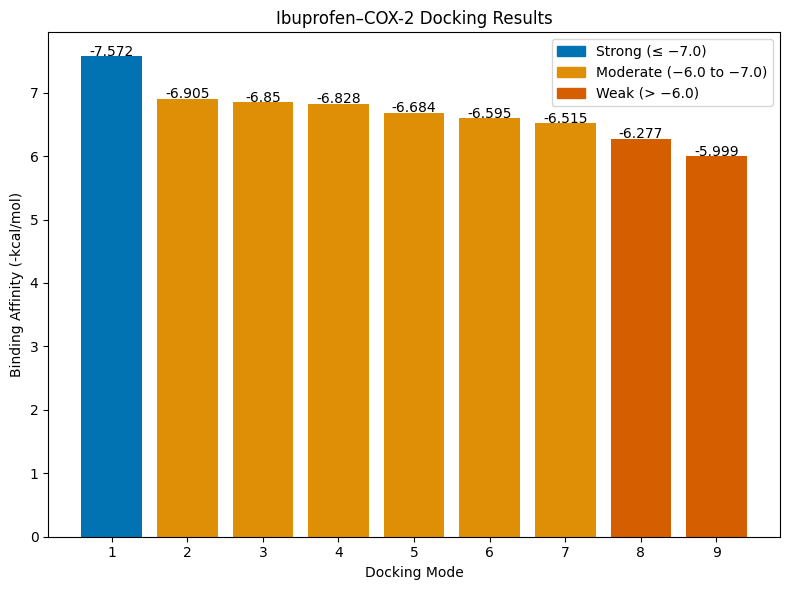

✅ Best binding: Mode 1 = -7.572 kcal/mol


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches   #patches for matplotlib's shape drawing part

# creating an empty list for scores
scores = []

with open('ibuprofen_docked.pdbqt', 'r') as f:
  for line in f:
    if 'REMARK VINA RESULT' in line:
      scores.append(float(line.split()[3]))

modes = list(range(1,(len(scores)+1)))

# coloring
p = sns.color_palette('colorblind')
colors = []

for s in scores:
  if s <= -7.0:
    colors.append(p[0])   #blue-strong

  elif s <= -6.5:
    colors.append(p[1])     #orange-moderate

  else:
    colors.append(p[3])   #red-week


# draw chart

fig, ax = plt.subplots(figsize = (8,6))       #fig--paper/background, ax--canvas

s_positive = [abs(s) for s in scores]  #positive scores(s)-- bars go upword

bars = ax.bar(modes, s_positive, color = colors)  # x--modes, y--s

#label

for bar, score in zip(bars, scores):
   x = bar.get_x() + bar.get_width()/2
   y = bar.get_height() + 0.005
   ax.text(x, y, f'{score}', ha = 'center')

# Title
ax.set_xlabel('Docking Mode')
ax.set_ylabel('Binding Affinity (-kcal/mol)')
ax.set_title('Ibuprofen–COX-2 Docking Results')
ax.set_xticks(modes)

# Legend
patches = [
    mpatches.Patch(color = p[0], label = 'Strong (≤ −7.0)'),
    mpatches.Patch(color = p[1], label = 'Moderate (−6.0 to −7.0)'),
    mpatches.Patch(color = p[3], label = 'Weak (> −6.0)')
]
ax.legend(handles = patches)


# save
plt.tight_layout()
plt.savefig('ibuprofen_docking_scores.png', dpi = 300)
plt.show()

print(f"✅ Best binding: Mode 1 = {scores[0]} kcal/mol")





